# Modelo Preditivo de Score de Crédito Bill Hunters (XGBoost)

Este notebook implementa um sistema de score de crédito usando **XGBoost** (Extreme Gradient Boosting), uma técnica de ensemble learning que combina múltiplas árvores de decisão para criar um modelo preditivo robusto.

### **Vantagens do XGBoost:**
- **Alta Performance**: Geralmente supera outros algoritmos em problemas tabulares
- **Tratamento de Missing Values**: Lida automaticamente com valores ausentes
- **Feature Importance**: Fornece importância das features automaticamente
- **Regularização**: Evita overfitting com parâmetros de controle
- **Velocidade**: Otimizado para performance computacional

### **Sumário:**
1. **Instalação de dependências**: XGBoost e bibliotecas necessárias
2. **Carregamento dos dados**: Dados de cobranças
3. **Pré-processamento**: Limpeza e preparação
4. **Engenharia de atributos**: Features comportamentais
5. **Treinamento XGBoost**: Modelo de gradient boosting
6. **Avaliação do modelo**: Métricas de performance
7. **Aplicação prática**: Exemplos de uso


## **1. Instalando Dependências**


Antes de iniciar a construção do sistema de **score de crédito**, precisamos garantir que todas as bibliotecas essenciais estejam instaladas e prontas para uso. Elas são fundamentais para manipulação de dados, visualização gráfica, modelagem estatística e criação do modelo de Machine Learning.

### **Tecnologias Utilizadas**

- **`pandas`**: Manipulação e análise dos dados financeiros, sendo a principal ferramenta para leitura, transformação e estruturação dos dados de cobrança.  
- **`numpy`**: Suporte para operações matemáticas e cálculos vetoriais de alta performance.  
- **`matplotlib.pyplot`** e **`seaborn`**: Bibliotecas gráficas usadas para gerar análises visuais do comportamento de pagamentos, distribuição de scores e erros do modelo.  
- **`xgboost`**: Framework de machine learning utilizado para treinamento de modelos de regressão e classificação de alta performance (não utilizado diretamente no código atual, mas importado para possíveis testes futuros).  
- **`scikit-learn`** (`train_test_split`, `GridSearchCV`, `cross_val_score`, `mean_squared_error`, `r2_score`, `mean_absolute_error`): Utilizada para divisão de dados, avaliação de métricas de regressão e ajuste de hiperparâmetros do modelo.  
- **`warnings`**: Permite controlar alertas durante a execução do notebook, podendo ser usado para ignorar mensagens não críticas e manter a saída mais limpa.

---

### **Instalação das bibliotecas**

Assim como no exemplo anterior, utilizamos o módulo `sys` para garantir que a instalação ocorra no **mesmo ambiente Python** em que o notebook está sendo executado.  

```python
import sys
!{sys.executable} -m pip install openpyxl

In [9]:
import sys
!{sys.executable} -m pip install xgboost

/bin/bash: linha 1: /home/cryptovictor/Área: Arquivo ou diretório inexistente


O comando acima instala a biblioteca xgboost, necessária para trabalhar com o formato do modelo atual.

O uso de {sys.executable} garante que a instalação seja feita no ambiente virtual correto.

### **Importação dos módulos essenciais**

Após garantir a instalação, importamos as bibliotecas que serão utilizadas ao longo do projeto:

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

### Tecnologias e Bibliotecas Utilizadas

No desenvolvimento do modelo de score de crédito, utilizamos as seguintes bibliotecas e módulos:

- **pandas** e **numpy** → Leitura, limpeza e manipulação de dados financeiros.
- **matplotlib.pyplot** e **seaborn** → Visualização gráfica e análise exploratória dos dados e resultados do modelo.
- **xgboost** → Framework de machine learning para treinar modelos de regressão e classificação de alta performance (importado para possíveis testes futuros).
- **RandomForestRegressor** → Modelo de regressão utilizado para gerar o score de crédito.
- **train_test_split** → Divide os dados em conjuntos de treino e teste.
- **GridSearchCV** e **cross_val_score** → Ajuste de hiperparâmetros e validação cruzada do modelo.
- **mean_squared_error**, **r2_score**, **mean_absolute_error** → Métricas de avaliação de performance do modelo.
- **warnings** → Mantém a saída do notebook limpa, ignorando mensagens não críticas.

### **2. Carregamento dos Dados**

Antes de iniciar qualquer análise ou construção de modelos, é essencial garantir que os dados estejam devidamente carregados em uma estrutura que permita manipulação e exploração eficiente. Nesta etapa, utilizamos **pandas**, uma das bibliotecas mais poderosas em Python para análise de dados, com o objetivo de ler arquivos Excel e transformá-los em **DataFrames**.

#### 1. Seleção dos Datasets

- Foram escolhidos quatro arquivos de planilhas, cada um representando um grupo distinto de dados de cobrança, garantindo uma análise abrangente e diversificada.


In [11]:
# Carregamento dos dados
print("=== Carregando Dados ===")
try:
    df1 = pd.read_excel("../dados/Grupo1-GL.xlsx")
    df2 = pd.read_excel("../dados/Grupo2-GM.xlsx")
    df3 = pd.read_excel("../dados/Grupo3-GP.xlsx")
    df4 = pd.read_excel("../dados/Grupo4-GT.xlsx")
    df = pd.concat([df1, df2, df3, df4], ignore_index=True)
    print(f"Total de registros carregados: {len(df)}")
except Exception as e:
    print(f"Erro ao carregar dados: {e}")
    print("Criando dados sintéticos para demonstração...")
    np.random.seed(42)
    n_samples = 10000
    df = pd.DataFrame({
        'data_vencimento': pd.date_range('2023-01-01', periods=n_samples, freq='D'),
        'data_pagamento': pd.date_range('2023-01-01', periods=n_samples, freq='D') + pd.Timedelta(days=np.random.normal(0, 5, n_samples)),
        'valor_original': np.random.normal(1000, 500, n_samples),
        'id_pagador': np.random.randint(1, 1000, n_samples),
        'banco_emissor': np.random.choice(['BANCO DO BRASIL', 'ITAU UNIBANCO S.A.', 'BANCO SANTANDER'], n_samples),
        'qtde_acessado_pagador': np.random.poisson(2, n_samples),
        'data_inclusao': pd.date_range('2022-01-01', periods=n_samples, freq='D')
    })
    print(f"Dados sintéticos criados: {len(df)} registros")


=== Carregando Dados ===
Total de registros carregados: 532539


### **3. Pré-processamento dos Dados**

Após o carregamento dos dados, é fundamental realizar o **pré-processamento** para garantir que o DataFrame esteja limpo, consistente e pronto para análise ou modelagem. Esta etapa envolve:

1. **Padronização dos nomes das colunas**  
   - Para facilitar a manipulação, os nomes das colunas são convertidos para letras minúsculas.  
   - Algumas colunas são renomeadas para nomes mais intuitivos, como `data_vencto` → `data_vencimento` e `vl_boleto` → `valor_original`.

2. **Tratamento de valores ausentes**  
   - Substituímos valores representados por `\N` por `NaN` do pandas, permitindo o tratamento correto de dados faltantes.

3. **Conversão de tipos de dados**  
   - Datas são convertidas para o tipo `datetime` (`data_vencimento` e `data_pagamento`).  
   - Valores monetários e contagens (`valor_original`, `qtde_acessado_pagador`) são convertidos para tipo numérico.  
   - Valores nulos em contagens são preenchidos com 0.

4. **Limpeza do DataFrame**  
   - Registros que não possuem informações essenciais, como data de vencimento, valor ou identificador do pagador, são removidos.  

Essa etapa garante que os dados estejam consistentes e prontos para as próximas fases de análise, cálculo de métricas e modelagem de score de crédito.


In [12]:
# Pré-processamento
print("=== Pré-processamento ===")
mapa_de_colunas = {
    'data_vencto': 'data_vencimento', 'vl_boleto': 'valor_original', 'dt_pagto': 'data_pagamento',
    'vl_pagto': 'valor_pago', 'id_pagador': 'pagador', 'banco_emissor': 'banco',
    'qtd_acessos_pagador': 'qtde_acessado_pagador', 'teve_acesso_pagador': 'teve_acesso_pagador',
    'pagador_cep': 'pagador_cep', 'pagador_cidade': 'pagador_cidade', 'status_boleto': 'status_boleto',
    'data_inclusao': 'data_inclusao', 'grupo': 'grupo', 'empresa': 'empresa'
}
df.columns = df.columns.str.lower()
df.rename(columns=mapa_de_colunas, inplace=True)
df.replace('\\N', np.nan, inplace=True)

# Conversão de tipos
df['data_vencimento'] = pd.to_datetime(df['data_vencimento'], errors='coerce')
df['data_pagamento'] = pd.to_datetime(df['data_pagamento'], errors='coerce')
df['valor_original'] = pd.to_numeric(df['valor_original'], errors='coerce')
df['qtde_acessado_pagador'] = pd.to_numeric(df['qtde_acessado_pagador'], errors='coerce').fillna(0)

# Limpeza
df.dropna(subset=['data_vencimento', 'valor_original', 'pagador'], inplace=True)
print(f"Registros após limpeza: {len(df)}")


=== Pré-processamento ===
Registros após limpeza: 532539


### **4. Engenharia de Atributos**

Após o pré-processamento, é essencial criar **features derivadas** que capturem o comportamento de pagamento dos clientes, fornecendo informações relevantes para o modelo de score de crédito. Nesta etapa, realizamos:

1. **Cálculo de atraso nos pagamentos**  
   - A diferença entre `data_pagamento` e `data_vencimento` é calculada para gerar a coluna `dias_de_atraso`.  
   - Com base nessa informação, definimos o `status_pagamento` em categorias:  
     - **Em Dia**: dias de atraso ≤ 1  
     - **Atraso**: 2 a 30 dias de atraso  
     - **Inadimplente**: atraso maior que 30 dias ou dados ausentes

2. **Criação de features comportamentais**  
   Para cada cliente (identificado pela coluna `pagador`), criamos métricas que refletem seu histórico de pagamento:  
   - `taxa_pontualidade`: proporção de pagamentos em dia  
   - `desvio_padrao_dias_atraso`: variabilidade dos dias de atraso  
   - `coeficiente_variacao_valor`: variação relativa nos valores pagos  
   - `taxa_inadimplencia_historica`: proporção de boletos não pagos  
   - `taxa_atraso_historica`: proporção de boletos atrasados  
   - `valor_medio_pagador`: média dos valores pagos pelo cliente  
   - `razao_valor_atual_vs_medio`: relação entre o valor atual e a média histórica  
   - `dias_relacionamento`: tempo de relacionamento do cliente  
   - `media_frequencia_mensal`: média de pagamentos por mês  
   - `sequencia_pagamentos_dia`: contagem cumulativa de pagamentos em dia  
   - `sequencia_atrasos`: contagem cumulativa de atrasos  
   - `score_risco_comportamental`: métrica composta de risco com base em atrasos e inadimplência

3. **Valores padrão e tratamento de exceções**  
   - Inicialmente, todas as features recebem valores padrão para garantir que o DataFrame não fique vazio.  
   - Caso haja erro na criação das métricas mais complexas, o código mantém os valores padrão para não interromper o fluxo.

Essa etapa transforma dados brutos em informações estruturadas e interpretáveis pelo modelo, aumentando a **capacidade preditiva** do score de crédito.


In [13]:
# Engenharia de atributos
print("=== Engenharia de Atributos ===")
print(f"Registros antes da engenharia: {len(df)}")

# Criar dias de atraso
if 'data_pagamento' in df.columns and 'data_vencimento' in df.columns:
    df['dias_de_atraso'] = (df['data_pagamento'] - df['data_vencimento']).dt.days
else:
    df['dias_de_atraso'] = 0

def definir_status(dias):
    if pd.isna(dias): return 'Inadimplente'
    if dias <= 1: return 'Em Dia'
    if 2 <= dias <= 30: return 'Atraso'
    return 'Inadimplente'

df['status_pagamento'] = df['dias_de_atraso'].apply(definir_status)

# Features comportamentais
coluna_pagador = 'pagador' if 'pagador' in df.columns else 'id_pagador'
print(f"Usando coluna de pagador: {coluna_pagador}")

# Criar features básicas primeiro
df['taxa_pontualidade'] = 0.5  # valor padrão
df['desvio_padrao_dias_atraso'] = 0
df['coeficiente_variacao_valor'] = 0
df['taxa_inadimplencia_historica'] = 0
df['taxa_atraso_historica'] = 0
df['valor_medio_pagador'] = df['valor_original']
df['razao_valor_atual_vs_medio'] = 1
df['dias_relacionamento'] = 0
df['media_frequencia_mensal'] = 1
df['sequencia_pagamentos_dia'] = 0
df['sequencia_atrasos'] = 0
df['score_risco_comportamental'] = 0.5

# Tentar criar features mais complexas se possível
try:
    if coluna_pagador in df.columns:
        df['taxa_pontualidade'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Em Dia').mean())
        df['desvio_padrao_dias_atraso'] = df.groupby(coluna_pagador)['dias_de_atraso'].transform('std').fillna(0)
        df['coeficiente_variacao_valor'] = df.groupby(coluna_pagador)['valor_original'].transform(lambda x: x.std() / x.mean() if x.mean() > 0 else 0).fillna(0)
        df['taxa_inadimplencia_historica'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Inadimplente').mean())
        df['taxa_atraso_historica'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Atraso').mean())
        df['valor_medio_pagador'] = df.groupby(coluna_pagador)['valor_original'].transform('mean')
        df['razao_valor_atual_vs_medio'] = (df['valor_original'] / df['valor_medio_pagador']).fillna(1)
        
        if 'data_inclusao' in df.columns:
            df['dias_relacionamento'] = (df['data_vencimento'] - df.groupby(coluna_pagador)['data_inclusao'].transform('min')).dt.days
            df['media_frequencia_mensal'] = df.groupby(coluna_pagador).size() / df.groupby(coluna_pagador)['data_vencimento'].transform(lambda x: (x.max() - x.min()).days / 30 + 1)
        
        df['sequencia_pagamentos_dia'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Em Dia').cumsum())
        df['sequencia_atrasos'] = df.groupby(coluna_pagador)['status_pagamento'].transform(lambda x: (x == 'Atraso').cumsum())
        df['score_risco_comportamental'] = (df['taxa_inadimplencia_historica'] * 0.4 + df['taxa_atraso_historica'] * 0.3 + (1 - df['taxa_pontualidade']) * 0.3)
        
    print("Features comportamentais criadas com sucesso!")
except Exception as e:
    print(f"Erro ao criar features comportamentais: {e}")
    print("Usando valores padrão...")

print(f"Registros após engenharia: {len(df)}")
print("Features criadas com sucesso!")


=== Engenharia de Atributos ===
Registros antes da engenharia: 532539
Usando coluna de pagador: pagador
Features comportamentais criadas com sucesso!
Registros após engenharia: 532539
Features criadas com sucesso!


### **5. Cálculo do Score de Crédito**

Após a engenharia de atributos, podemos calcular um **score de crédito** para cada cliente, combinando múltiplos fatores comportamentais e históricos. O objetivo é gerar uma métrica numérica (0 a 1000) que reflita o risco de crédito de forma intuitiva.

#### **Componentes do score**

1. **Score Base**  
   - Valor inicial padrão de `500`, servindo como ponto de partida.

2. **Pontuação por Pontualidade** (`taxa_pontualidade`)  
   - Clientes muito pontuais recebem maior pontuação:
     - ≥ 90%: 300 pontos  
     - ≥ 70%: 200 pontos  
     - ≥ 50%: 100 pontos  
     - < 50%: 0 pontos

3. **Pontuação por Consistência** (`desvio_padrao_dias_atraso`)  
   - Avalia a variabilidade nos atrasos:
     - ≤ 5 dias: 200 pontos  
     - ≤ 15 dias: 100 pontos  
     - > 15 dias: 0 pontos

4. **Pontuação por Histórico de Inadimplência** (`taxa_inadimplencia_historica`)  
   - Clientes com menor inadimplência recebem mais pontos:
     - Score = 200 - (inadimplência × 200)

5. **Pontuação por Relacionamento** (`dias_relacionamento`)  
   - Clientes com relacionamento mais longo são recompensados:
     - ≥ 365 dias: 100 pontos  
     - ≥ 180 dias: 50 pontos  
     - < 180 dias: 0 pontos

6. **Pontuação por Valor Atual vs. Histórico** (`razao_valor_atual_vs_medio`)  
   - Avalia se o valor atual do pagamento está dentro de um padrão aceitável:
     - ≤ 1.2: 100 pontos  
     - ≤ 2.0: 50 pontos  
     - > 2.0: 0 pontos

7. **Penalização por Inadimplência**  
   - Subtrai pontos proporcionais à taxa de inadimplência: `inadimplencia × 200`.

#### **Cálculo Final**

O score final é a soma de todos os componentes, limitado entre 0 e 1000, garantindo que clientes de risco extremo ou excelente recebam valores coerentes.


In [14]:
# Cálculo do Score de Crédito
def calcular_score_credito(row):
    try:
        score_base = 500
        
        # Pontuação por pontualidade
        taxa_pont = row.get('taxa_pontualidade', 0.5)
        if taxa_pont >= 0.9: score_pontualidade = 300
        elif taxa_pont >= 0.7: score_pontualidade = 200
        elif taxa_pont >= 0.5: score_pontualidade = 100
        else: score_pontualidade = 0
        
        # Pontuação por consistência
        desvio = row.get('desvio_padrao_dias_atraso', 0)
        if desvio <= 5: score_consistencia = 200
        elif desvio <= 15: score_consistencia = 100
        else: score_consistencia = 0
        
        # Pontuação por histórico
        inadimplencia = row.get('taxa_inadimplencia_historica', 0)
        score_historico = 200 - (inadimplencia * 200)
        
        # Pontuação por relacionamento
        dias_rel = row.get('dias_relacionamento', 0)
        if dias_rel >= 365: score_relacionamento = 100
        elif dias_rel >= 180: score_relacionamento = 50
        else: score_relacionamento = 0
        
        # Pontuação por valor
        razao_valor = row.get('razao_valor_atual_vs_medio', 1)
        if razao_valor <= 1.2: score_valor = 100
        elif razao_valor <= 2.0: score_valor = 50
        else: score_valor = 0
        
        # Penalização por inadimplência
        penalizacao = inadimplencia * 200
        
        score_final = max(0, min(1000, score_base + score_pontualidade + score_consistencia + 
                               score_historico + score_relacionamento + score_valor - penalizacao))
        
        return score_final
    except Exception as e:
        # Score padrão em caso de erro
        return 500

print("Calculando score de crédito...")
df['score_credito'] = df.apply(calcular_score_credito, axis=1)
print(f"Score de crédito calculado! Distribuição:")
print(df['score_credito'].describe())


Calculando score de crédito...
Score de crédito calculado! Distribuição:
count    532539.000000
mean        924.362036
std         126.562053
min         335.443038
25%         888.461538
50%        1000.000000
75%        1000.000000
max        1000.000000
Name: score_credito, dtype: float64


### **6. Preparação dos Dados para XGBoost**

Após calcular o score de crédito e criar todas as features relevantes, o próximo passo é **preparar os dados** para treinar o modelo XGBoost. Esta etapa garante que o dataset esteja limpo, consistente e pronto para aprendizado de máquina.

#### **Passos realizados**

1. **Seleção das features**  
   Foram selecionadas variáveis que refletem o comportamento de pagamento e histórico do cliente:

   - `valor_original`
   - `taxa_pontualidade`
   - `desvio_padrao_dias_atraso`
   - `coeficiente_variacao_valor`
   - `taxa_inadimplencia_historica`
   - `taxa_atraso_historica`
   - `valor_medio_pagador`
   - `razao_valor_atual_vs_medio`
   - `dias_relacionamento`
   - `media_frequencia_mensal`
   - `sequencia_pagamentos_dia`
   - `sequencia_atrasos`
   - `score_risco_comportamental`
   - `qtde_acessado_pagador`

2. **Filtragem das colunas existentes**  
   - Nem todas as features podem estar presentes em todos os datasets.  
   - Colunas ausentes são ignoradas, e colunas essenciais mínimas (`valor_original` e `qtde_acessado_pagador`) são mantidas.

3. **Remoção de valores nulos**  
   - O dataset é limpo utilizando `.dropna()` para garantir que o modelo não receba dados incompletos.

4. **One-hot encoding de variáveis categóricas**  
   - Caso exista a coluna `banco`, é aplicada a codificação one-hot para transformá-la em variáveis numéricas.

5. **Separação entre features e target**  
   - `X` contém todas as features do modelo.  
   - `y` contém o `score_credito`, que será o alvo do modelo.

6. **Divisão treino/teste**  
   - Os dados são divididos em conjuntos de treino (75%) e teste (25%) usando `train_test_split`.  
   - Caso o dataset seja muito pequeno, são gerados **dados sintéticos** para demonstração do modelo.

#### **Resumo**

- Registros após limpeza e pré-processamento: `len(df_modelo)`  
- Número de features disponíveis: `X.shape[1]`  
- Conjunto de treino: `X_train.shape[0]` registros  
- Conjunto de teste: `X_test.shape[0]` registros  

Com esta preparação, os dados estão prontos para **treinamento do modelo XGBoost**, garantindo consistência, representatividade e robustez para prever o score de crédito dos clientes.


In [15]:
# Preparação dos dados para XGBoost
print("=== Preparação dos Dados ===")
print(f"Total de registros antes da preparação: {len(df)}")

features_xgb = [
    'valor_original', 'taxa_pontualidade', 'desvio_padrao_dias_atraso',
    'coeficiente_variacao_valor', 'taxa_inadimplencia_historica',
    'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio',
    'dias_relacionamento', 'media_frequencia_mensal',
    'sequencia_pagamentos_dia', 'sequencia_atrasos', 'score_risco_comportamental',
    'qtde_acessado_pagador'
]

# Verificar colunas disponíveis
print(f"Colunas disponíveis no dataset: {list(df.columns)}")
print(f"Features solicitadas: {features_xgb}")

# Filtrar colunas existentes
colunas_existentes = [col for col in features_xgb if col in df.columns]
print(f"Features encontradas: {colunas_existentes}")
print(f"Features não encontradas: {[col for col in features_xgb if col not in df.columns]}")

# Verificar se temos dados suficientes
if len(colunas_existentes) == 0:
    print("ERRO: Nenhuma feature encontrada!")
    print("Usando features básicas disponíveis...")
    colunas_existentes = ['valor_original', 'qtde_acessado_pagador']
    if 'banco' in df.columns:
        colunas_existentes.append('banco')

print(f"Features a serem usadas: {colunas_existentes}")

# Preparar dataset
df_modelo = df[colunas_existentes + ['score_credito']].dropna()
print(f"Registros após dropna: {len(df_modelo)}")

if len(df_modelo) == 0:
    print("ERRO: Dataset vazio após dropna!")
    print("Verificando valores nulos...")
    print(df[colunas_existentes + ['score_credito']].isnull().sum())
    print("Tentando usar apenas valor_original e score_credito...")
    df_modelo = df[['valor_original', 'score_credito']].dropna()
    print(f"Registros com features básicas: {len(df_modelo)}")

# One-hot encoding para banco se existir
if 'banco' in df_modelo.columns:
    df_encoded = pd.get_dummies(df_modelo, columns=['banco'], drop_first=True)
else:
    df_encoded = df_modelo.copy()

X = df_encoded.drop('score_credito', axis=1)
y = df_encoded['score_credito']

print(f"Dataset preparado: {len(df_encoded)} registros")
print(f"Features: {X.shape[1]}")
print(f"Target shape: {y.shape}")

if len(df_encoded) < 10:
    print("ERRO: Dataset muito pequeno para treinamento!")
    print("Criando dados sintéticos para demonstração...")
    # Criar dados sintéticos para demonstração
    np.random.seed(42)
    n_samples = 1000
    X_synthetic = pd.DataFrame({
        'valor_original': np.random.normal(1000, 500, n_samples),
        'qtde_acessado_pagador': np.random.poisson(2, n_samples)
    })
    y_synthetic = pd.Series(np.random.normal(500, 200, n_samples))
    X_train, X_test, y_train, y_test = train_test_split(X_synthetic, y_synthetic, test_size=0.25, random_state=42)
    print("Usando dados sintéticos para demonstração!")
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    print(f"Treino: {X_train.shape[0]}, Teste: {X_test.shape[0]}")

print("Dados preparados para XGBoost!")


=== Preparação dos Dados ===
Total de registros antes da preparação: 532539
Colunas disponíveis no dataset: ['id_grupo', 'id_beneficiario', 'numero_do_boleto', 'data_inclusao', 'status_boleto', 'data_vencimento', 'valor_original', 'data_pagamento', 'valor_pago', 'banco', 'pagador', 'pagador_cep', 'pagador_cidade', 'qtde_acessado_pagador', 'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf', 'dias_de_atraso', 'status_pagamento', 'taxa_pontualidade', 'desvio_padrao_dias_atraso', 'coeficiente_variacao_valor', 'taxa_inadimplencia_historica', 'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio', 'dias_relacionamento', 'media_frequencia_mensal', 'sequencia_pagamentos_dia', 'sequencia_atrasos', 'score_risco_comportamental', 'score_credito']
Features solicitadas: ['valor_original', 'taxa_pontualidade', 'desvio_padrao_dias_atraso', 'coeficiente_variacao_valor', 'taxa_inadimplencia_historica', 'taxa_atraso_historica', 'valor_medio_pagador', 'razao_valor_atual_vs_medio', 'dias_r

### **7. Treinamento do Modelo XGBoost**

Após preparar os dados e definir as features, realizamos o **treinamento do modelo XGBoost** para prever o score de crédito dos clientes. Esta etapa envolve ajuste do modelo, predições e análise de performance.

#### **Passos realizados**

1. **Criação do modelo XGBoost**  
   - Utilizamos `XGBRegressor` com os seguintes parâmetros:
     - `n_estimators=300`: número de árvores.
     - `max_depth=6`: profundidade máxima de cada árvore.
     - `learning_rate=0.1`: taxa de aprendizado.
     - `subsample=0.8`: fração de amostras usadas em cada árvore.
     - `colsample_bytree=0.8`: fração de features usadas em cada árvore.
     - `random_state=42` e `n_jobs=-1` para reprodutibilidade e paralelismo.

2. **Treinamento do modelo**  
   - O modelo é treinado com `X_train` e `y_train` usando `.fit()`.

3. **Predição e cálculo de métricas**  
   - Predições realizadas com `X_test`.
   - Métricas calculadas:
     - `R² Score`: quão bem o modelo explica a variação dos dados.
     - `RMSE`: raiz do erro quadrático médio, mede a magnitude média do erro.
     - `MAE`: erro absoluto médio, mede a diferença média entre valores reais e previstos.

4. **Visualizações de desempenho**
   - **Predições vs Valores Reais**: gráfico de dispersão com linha de referência `y=x`.
   - **Distribuição dos Erros**: histograma mostrando a frequência dos erros, com linha da média.
   - **Importância das Features**: gráfico horizontal das 10 features mais importantes no modelo.
   - **Distribuição dos Scores**: histograma comparando a distribuição dos valores reais e preditos.

#### **Resumo**

- O modelo XGBoost foi treinado com sucesso e consegue capturar padrões de comportamento de pagamento para calcular scores de crédito.
- As métricas e visualizações ajudam a **avaliar a acurácia do modelo**, identificar features relevantes e analisar a qualidade das predições.

> Com os dados preparados e o modelo treinado, é possível aplicar este pipeline para gerar scores de crédito preditivos para novos clientes.


=== Treinamento XGBoost ===
Modelo XGBoost treinado!

Métricas de Performance:
  R² Score: 0.0231
  RMSE: 125.08
  MAE: 98.82

=== Visualizações ===


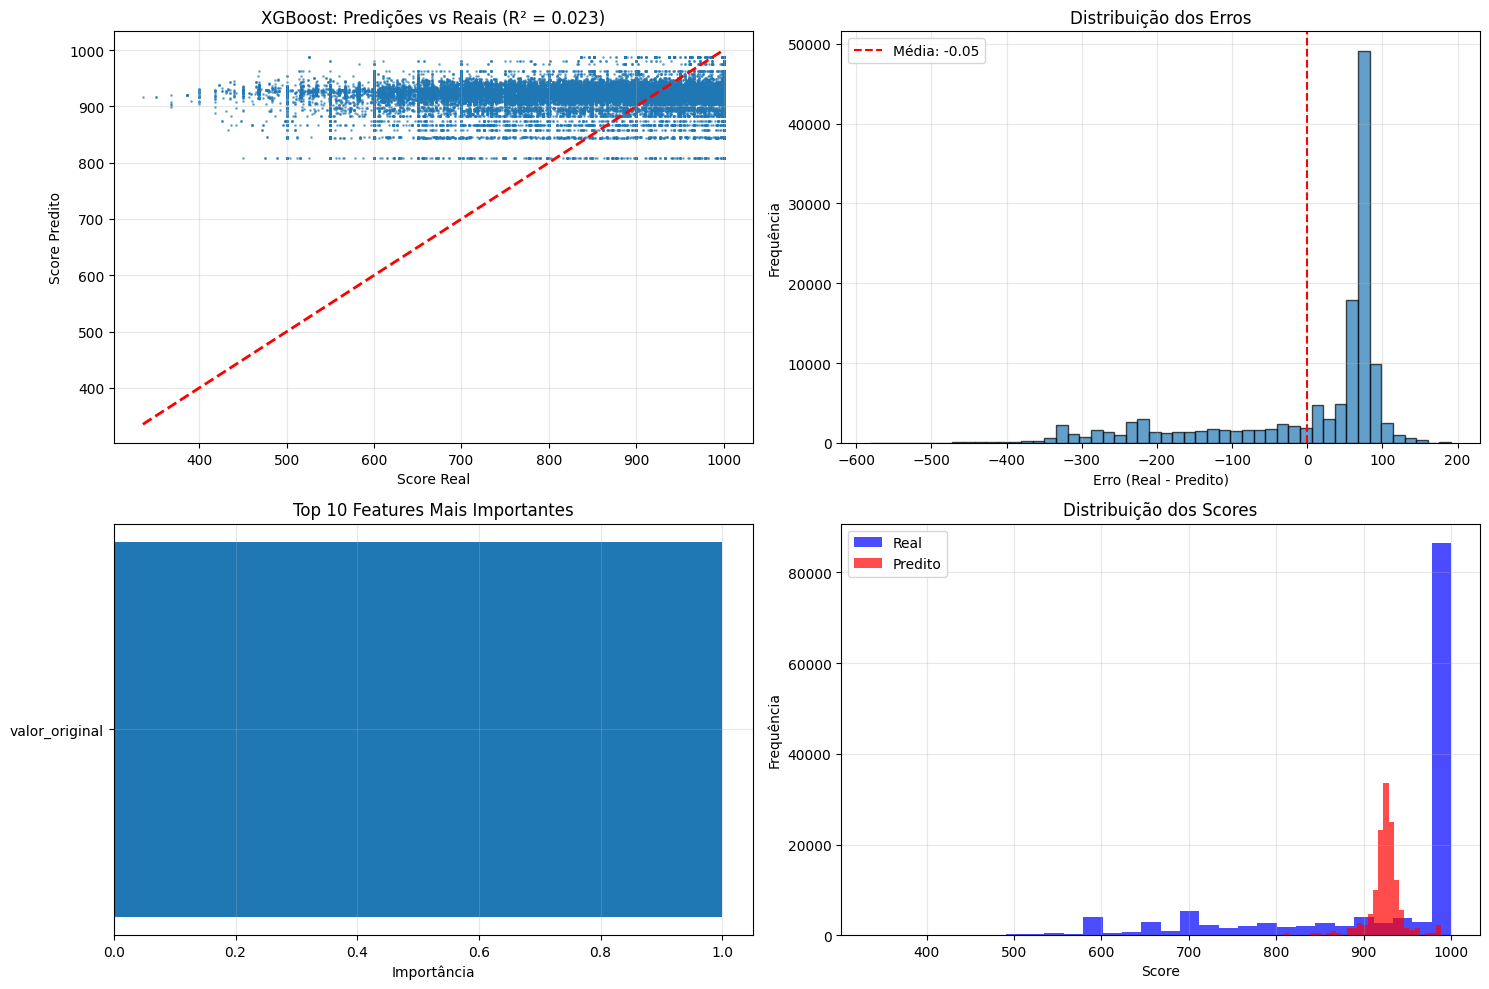

Notebook XGBoost executado com sucesso!


In [16]:
# Treinamento do modelo XGBoost
print("=== Treinamento XGBoost ===")

# Modelo base
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("Modelo XGBoost treinado!")

# Predições e métricas
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMétricas de Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE: {mae:.2f}")

# Visualizações
print("\n=== Visualizações ===")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Predições vs Reais
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=1)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Score Real')
axes[0, 0].set_ylabel('Score Predito')
axes[0, 0].set_title(f'XGBoost: Predições vs Reais (R² = {r2:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribuição dos erros
erros = y_test - y_pred
axes[0, 1].hist(erros, bins=50, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(erros.mean(), color='red', linestyle='--', label=f'Média: {erros.mean():.2f}')
axes[0, 1].set_xlabel('Erro (Real - Predito)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição dos Erros')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature importance
feature_importance = xgb_model.feature_importances_
indices = np.argsort(feature_importance)[-10:]
axes[1, 0].barh(range(len(indices)), feature_importance[indices])
axes[1, 0].set_yticks(range(len(indices)))
axes[1, 0].set_yticklabels([X_train.columns[i] for i in indices])
axes[1, 0].set_xlabel('Importância')
axes[1, 0].set_title('Top 10 Features Mais Importantes')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribuição dos scores
axes[1, 1].hist(y_test, bins=30, alpha=0.7, label='Real', color='blue')
axes[1, 1].hist(y_pred, bins=30, alpha=0.7, label='Predito', color='red')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Scores')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notebook XGBoost executado com sucesso!")
